# Notebook 04 — DistilBERT Fine-Tuning
**Project:** Automated Credit Card Dispute Resolution via NLP  
**Baseline (nb03):** 82.44% accuracy (TF-IDF + Logistic Regression)  

---
### ⚠️ Run this notebook on Google Colab with T4 GPU
Runtime → Change runtime type → **T4 GPU**  
Estimated training time: **25–40 minutes**

## Step 1 — Install dependencies & verify GPU

In [1]:
# Install required packages (Colab already has most, but pin versions)
!pip install transformers==4.40.0 datasets==2.19.0 accelerate==0.30.0 -q

import torch
print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")
    print(f"VRAM            : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected! Go to Runtime → Change runtime type → T4 GPU")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 94.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 43.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.4/302.4 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 126.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.3.1 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.

## Step 2 — Mount Google Drive & load dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ── UPDATE THIS PATH if your CSV is in a different folder ──────────────
DATA_PATH = '/content/drive/MyDrive/labeled_complaints.csv'
# ──────────────────────────────────────────────────────────────────────

import pandas as pd

df = pd.read_csv(DATA_PATH)
print(f"Dataset loaded: {df.shape}")
print(f"\nCategory distribution:")
print(df['transaction_category'].value_counts())
df = df.dropna(subset=['complaint_text_clean', 'transaction_category'])
print(f"\n✅ Ready: {len(df):,} rows")

Mounted at /content/drive
Dataset loaded: (30000, 9)

Category distribution:
transaction_category
Service Not Provided        5000
Merchant Fraud              5000
Duplicate Charge            5000
Unauthorized Transaction    5000
Billing Error               5000
Goods Not Received          5000
Name: count, dtype: int64

✅ Ready: 30,000 rows


In [3]:
# ── CELL: BERT-FRIENDLY PREPROCESSING + LABEL CLEANUP ─────────────────

import re
import pandas as pd

def clean_for_bert(text):
    """
    BERT-friendly cleaning — preserves grammar and punctuation.
    Only replaces XXXX placeholders with meaningful tokens.
    """
    text = str(text)
    # Replace date placeholders with DATE token (not delete)
    text = re.sub(r'\bXX/XX/(?:XXXX|\d{4})\b', 'DATE', text)
    text = re.sub(r'\bXX/XX\b', 'DATE', text)
    text = re.sub(r'\bXXXX\b', 'REDACTED', text)
    # Replace dollar amounts with AMOUNT token (not delete)
    text = re.sub(r'\{\$[\d,]+\.?\d*\}', 'AMOUNT', text)
    text = re.sub(r'\$[\d,]+\.?\d*', 'AMOUNT', text)
    # Remove only truly noisy patterns (URLs, emails)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    # Normalize whitespace only
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Apply new cleaning to complaint_text (raw column)
df['bert_text'] = df['complaint_text'].apply(clean_for_bert)

# ── LABEL CLEANUP: fix Billing Error / Unauthorized overlap ─────────────

UNAUTHORIZED_SIGNALS = [
    'did not authorize', 'did not make', 'not authorize',
    'unauthorized charge', 'unauthorized transaction',
    'someone used my card', 'fraudulent charge', 'identity theft',
    'card was stolen', 'card stolen', 'without my permission',
    'not my purchase', 'never made this'
]

BILLING_ERROR_ANCHORS = [
    'late fee', 'interest charge', 'annual fee', 'fee was charged',
    'overcharged', 'incorrect charge', 'wrong amount', 'billing error',
    'statement error', 'billing statement', 'finance charge',
    'balance was wrong', 'payment was applied'
]

def fix_billing_label(row):
    cat  = row['transaction_category']
    text = str(row['bert_text']).lower()

    # If labeled Billing Error but has strong unauthorized signals → relabel
    if cat == 'Billing Error':
        if any(sig in text for sig in UNAUTHORIZED_SIGNALS):
            # Only relabel if no billing anchor present (true ambiguous cases)
            if not any(anchor in text for anchor in BILLING_ERROR_ANCHORS):
                return 'Unauthorized Transaction'
    return cat

original_dist = df['transaction_category'].value_counts()
df['transaction_category'] = df.apply(fix_billing_label, axis=1)
new_dist = df['transaction_category'].value_counts()

print("Label changes:")
diff = new_dist - original_dist
print(diff[diff != 0])

# ── FILTER very short complaints (< 20 words) ──────────────────────────
before = len(df)
df = df[df['bert_text'].str.split().str.len() >= 20].reset_index(drop=True)
print(f"\nRemoved {before - len(df)} complaints under 20 words")
print(f"Remaining: {len(df):,} rows")

# ── Re-balance to 5000 per class ──────────────────────────────────────
from sklearn.utils import resample

balanced_dfs = []
for cat in df['transaction_category'].unique():
    subset = df[df['transaction_category'] == cat]
    if len(subset) >= 5000:
        balanced_dfs.append(resample(subset, n_samples=5000, random_state=42))
    else:
        balanced_dfs.append(resample(subset, n_samples=5000,
                                     replace=True, random_state=42))

df = pd.concat(balanced_dfs).sample(frac=1, random_state=42).reset_index(drop=True)
print(f"\nFinal dataset: {len(df):,} rows")
print(df['transaction_category'].value_counts())

# ── NOW use bert_text as X (not complaint_text_clean) ─────────────────
X = df['bert_text'].tolist()
y = df['transaction_category'].tolist()
print("\n✅ Ready for training — using bert_text column")

Label changes:
transaction_category
Billing Error              -337
Unauthorized Transaction    337
Name: count, dtype: int64

Removed 235 complaints under 20 words
Remaining: 29,765 rows

Final dataset: 30,000 rows
transaction_category
Service Not Provided        5000
Billing Error               5000
Goods Not Received          5000
Merchant Fraud              5000
Duplicate Charge            5000
Unauthorized Transaction    5000
Name: count, dtype: int64

✅ Ready for training — using bert_text column


## Step 3 — Encode labels & split data

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['transaction_category'])

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# 70 / 15 / 15 split — same as baseline for fair comparison
X = df['bert_text'].tolist()
y = df['label'].tolist()

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp
)

print(f"\nSplit sizes:")
print(f"  Train : {len(X_train):,}")
print(f"  Val   : {len(X_val):,}")
print(f"  Test  : {len(X_test):,}")

Label mapping:
  0 → Billing Error
  1 → Duplicate Charge
  2 → Goods Not Received
  3 → Merchant Fraud
  4 → Service Not Provided
  5 → Unauthorized Transaction

Split sizes:
  Train : 21,012
  Val   : 4,488
  Test  : 4,500


## Step 4 — Tokenize with DistilBERT tokenizer

In [5]:
from transformers import DistilBertTokenizerFast

MODEL_NAME = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

MAX_LEN = 256

def tokenize_batch(texts):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=MAX_LEN,
        return_tensors='pt'
    )

print(f"Tokenizer loaded: {MODEL_NAME}")
print(f"Max token length : {MAX_LEN}")

# Quick sanity check
sample = tokenize_batch([X_train[0]])
print(f"Sample input_ids shape: {sample['input_ids'].shape}")
print(f"Sample text preview: {X_train[0][:100]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Tokenizer loaded: distilbert-base-uncased
Max token length : 256
Sample input_ids shape: torch.Size([1, 135])
Sample text preview: I have a paypal credit account and I used it to purchase three eyeglass frames from REDACTED. When t...


## Step 5 — Build PyTorch Dataset class

In [6]:
import torch
from torch.utils.data import Dataset, DataLoader

class DisputeDataset(Dataset):
    """
    PyTorch Dataset for credit card dispute complaints.
    Tokenizes text on-the-fly with DistilBERT tokenizer.
    """
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            truncation=True,
            max_length=self.max_len,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'      : encoding['input_ids'].squeeze(),
            'attention_mask' : encoding['attention_mask'].squeeze(),
            'labels'         : torch.tensor(self.labels[idx], dtype=torch.long)
        }

BATCH_SIZE = 16   # Works well on T4 GPU with MAX_LEN=256

train_dataset = DisputeDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset   = DisputeDataset(X_val,   y_val,   tokenizer, MAX_LEN)
test_dataset  = DisputeDataset(X_test,  y_test,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print(f"Batch size    : {BATCH_SIZE}")

Train batches : 1314
Val batches   : 281
Test batches  : 282
Batch size    : 16


## Step 6 — Load DistilBERT model

In [7]:
from transformers import DistilBertForSequenceClassification

NUM_CLASSES = len(le.classes_)
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES
)
model = model.to(DEVICE)

# Count trainable parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model          : DistilBERT for Sequence Classification")
print(f"Device         : {DEVICE}")
print(f"Num classes    : {NUM_CLASSES}")
print(f"Total params   : {total_params:,}")
print(f"Trainable      : {trainable_params:,}")
print(f"\nClasses: {list(le.classes_)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model          : DistilBERT for Sequence Classification
Device         : cuda
Num classes    : 6
Total params   : 66,958,086
Trainable      : 66,958,086

Classes: ['Billing Error', 'Duplicate Charge', 'Goods Not Received', 'Merchant Fraud', 'Service Not Provided', 'Unauthorized Transaction']


## Step 7 — Set up optimizer and scheduler

In [8]:
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

EPOCHS        = 6
LEARNING_RATE = 1e-5
WARMUP_RATIO  = 0.2

optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=0.01   # L2 regularization
)

total_steps   = len(train_loader) * EPOCHS
warmup_steps  = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f"Epochs          : {EPOCHS}")
print(f"Learning rate   : {LEARNING_RATE}")
print(f"Total steps     : {total_steps}")
print(f"Warmup steps    : {warmup_steps}")
print(f"Est. train time : ~{total_steps * 0.12 / 60:.0f}–{total_steps * 0.18 / 60:.0f} min on T4 GPU")

Epochs          : 6
Learning rate   : 1e-05
Total steps     : 7884
Warmup steps    : 1576
Est. train time : ~16–24 min on T4 GPU


## Step 8 — Training loop with early stopping

In [9]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, all_preds, all_labels = 0, [], []

    for batch_idx, batch in enumerate(loader):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        logits  = outputs.logits

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # gradient clipping
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

        if (batch_idx + 1) % 100 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} | Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    return avg_loss, acc


def evaluate(model, loader, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc      = accuracy_score(all_labels, all_preds)
    f1       = f1_score(all_labels, all_preds, average='weighted')
    return avg_loss, acc, f1, all_preds, all_labels

print("✅ Training and evaluation functions ready")

✅ Training and evaluation functions ready


In [10]:
import os

# Training config
PATIENCE     = 2     # stop if val accuracy doesn't improve for 2 epochs
MODEL_SAVE   = '/content/drive/MyDrive/bert_dispute_model'  # saved to Drive
os.makedirs(MODEL_SAVE, exist_ok=True)

history           = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'val_f1': []}
best_val_acc      = 0
patience_counter  = 0

print("=" * 60)
print("   STARTING DISTILBERT FINE-TUNING")
print("=" * 60)

for epoch in range(1, EPOCHS + 1):
    print(f"\n{'='*60}")
    print(f"  EPOCH {epoch}/{EPOCHS}")
    print(f"{'='*60}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, DEVICE)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, DEVICE)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\n  Train Loss : {train_loss:.4f}  |  Train Acc : {train_acc*100:.2f}%")
    print(f"  Val Loss   : {val_loss:.4f}  |  Val Acc   : {val_acc*100:.2f}%  |  Val F1: {val_f1*100:.2f}%")

    # Save if best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        model.save_pretrained(MODEL_SAVE)
        tokenizer.save_pretrained(MODEL_SAVE)
        print(f"  ✅ New best model saved! Val Acc: {val_acc*100:.2f}%")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{PATIENCE}")
        if patience_counter >= PATIENCE:
            print("\n⏹️  Early stopping triggered.")
            break

print(f"\n{'='*60}")
print(f"  TRAINING COMPLETE")
print(f"  Best Validation Accuracy: {best_val_acc*100:.2f}%")
print(f"{'='*60}")

   STARTING DISTILBERT FINE-TUNING

  EPOCH 1/6
  Batch 100/1314 | Loss: 1.7632
  Batch 200/1314 | Loss: 1.7845
  Batch 300/1314 | Loss: 1.7840
  Batch 400/1314 | Loss: 1.7594
  Batch 500/1314 | Loss: 1.6702
  Batch 600/1314 | Loss: 1.6737
  Batch 700/1314 | Loss: 1.5432
  Batch 800/1314 | Loss: 1.1684
  Batch 900/1314 | Loss: 1.0419
  Batch 1000/1314 | Loss: 1.3751
  Batch 1100/1314 | Loss: 0.8296
  Batch 1200/1314 | Loss: 1.2783
  Batch 1300/1314 | Loss: 0.6604

  Train Loss : 1.4651  |  Train Acc : 41.20%
  Val Loss   : 0.9187  |  Val Acc   : 67.31%  |  Val F1: 67.26%
  ✅ New best model saved! Val Acc: 67.31%

  EPOCH 2/6
  Batch 100/1314 | Loss: 1.0505
  Batch 200/1314 | Loss: 1.0145
  Batch 300/1314 | Loss: 0.5227
  Batch 400/1314 | Loss: 0.3036
  Batch 500/1314 | Loss: 0.8581
  Batch 600/1314 | Loss: 0.6870
  Batch 700/1314 | Loss: 0.3470
  Batch 800/1314 | Loss: 0.5898
  Batch 900/1314 | Loss: 0.9325
  Batch 1000/1314 | Loss: 0.3045
  Batch 1100/1314 | Loss: 0.4223
  Batch 1200/

## Step 9 — Plot training curves

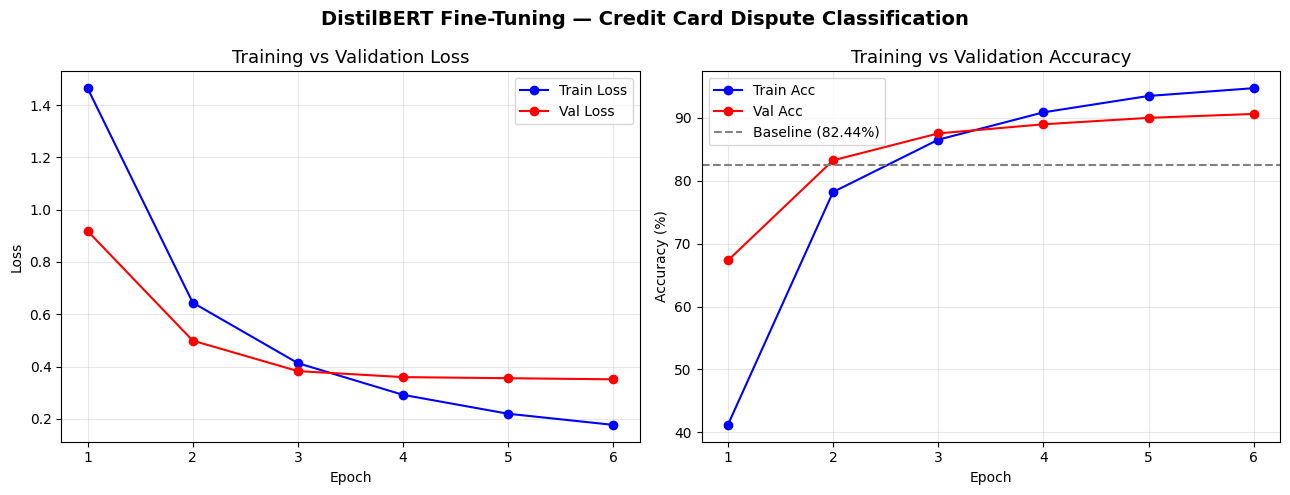

✅ Saved to Drive: bert_training_curves.png


In [11]:
import matplotlib.pyplot as plt

epochs_ran = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Loss
axes[0].plot(epochs_ran, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_ran, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Training vs Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc')
axes[1].plot(epochs_ran, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc')
axes[1].axhline(y=82.44, color='gray', linestyle='--', label='Baseline (82.44%)')
axes[1].set_title('Training vs Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('DistilBERT Fine-Tuning — Credit Card Dispute Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bert_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to Drive: bert_training_curves.png")

## Step 10 — Final evaluation on test set

In [12]:
from transformers import DistilBertForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best saved model
best_model = DistilBertForSequenceClassification.from_pretrained(MODEL_SAVE)
best_model = best_model.to(DEVICE)

test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(best_model, test_loader, DEVICE)

print("=" * 60)
print("   DISTILBERT — TEST SET RESULTS")
print("=" * 60)
print(f"  Test Accuracy : {test_acc*100:.2f}%")
print(f"  Test F1 Score : {test_f1*100:.2f}%")
print()
print("Comparison with Baseline:")
print(f"  Baseline Accuracy : 82.44%")
print(f"  DistilBERT Accuracy: {test_acc*100:.2f}%")
print(f"  Improvement       : +{(test_acc - 0.8244)*100:.2f}%")
print()
print("Per-category breakdown:")
print(classification_report(test_labels, test_preds, target_names=le.classes_))

   DISTILBERT — TEST SET RESULTS
  Test Accuracy : 89.98%
  Test F1 Score : 90.00%

Comparison with Baseline:
  Baseline Accuracy : 82.44%
  DistilBERT Accuracy: 89.98%
  Improvement       : +7.54%

Per-category breakdown:
                          precision    recall  f1-score   support

           Billing Error       0.81      0.86      0.83       750
        Duplicate Charge       0.98      0.97      0.98       750
      Goods Not Received       0.91      0.91      0.91       750
          Merchant Fraud       0.88      0.88      0.88       750
    Service Not Provided       0.91      0.93      0.92       750
Unauthorized Transaction       0.91      0.85      0.88       750

                accuracy                           0.90      4500
               macro avg       0.90      0.90      0.90      4500
            weighted avg       0.90      0.90      0.90      4500



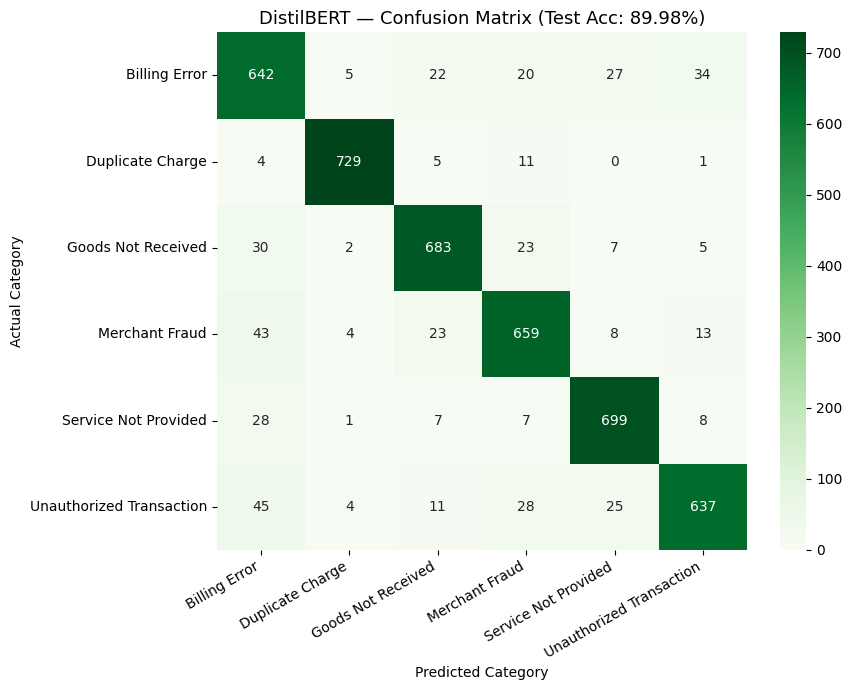

✅ Saved to Drive: bert_confusion_matrix.png


In [13]:
# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.title(f'DistilBERT — Confusion Matrix (Test Acc: {test_acc*100:.2f}%)', fontsize=13)
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/bert_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to Drive: bert_confusion_matrix.png")

## Step 11 — Save label encoder (for FastAPI backend)

In [ ]:
import joblib

# Save label encoder alongside the BERT model
# FastAPI will need this to decode predictions back to category names
joblib.dump(le, os.path.join(MODEL_SAVE, 'label_encoder.pkl'))

print("✅ All model artifacts saved to Google Drive:")
print(f"   {MODEL_SAVE}/")
print(f"   ├── config.json")
print(f"   ├── model.safetensors    ← BERT weights")
print(f"   ├── tokenizer.json")
print(f"   ├── tokenizer_config.json")
print(f"   ├── vocab.txt")
print(f"   └── label_encoder.pkl   ← category name decoder")
print()

✅ All model artifacts saved to Google Drive:
   /content/drive/MyDrive/bert_dispute_model/
   ├── config.json
   ├── model.safetensors    ← BERT weights
   ├── tokenizer.json
   ├── tokenizer_config.json
   ├── vocab.txt
   └── label_encoder.pkl   ← category name decoder

📥 Download this folder to: backend/models/bert_dispute_model/


## Step 12 — Live prediction demo

In [15]:
def predict_bert(text, model, tokenizer, le, device, max_len=128):
    """
    Predict dispute category using DistilBERT.
    Returns category name and confidence score.
    """
    model.eval()
    encoding = tokenizer(
        text,
        truncation=True,
        max_length=max_len,
        padding='max_length',
        return_tensors='pt'
    )
    input_ids      = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()[0]
        pred    = probs.argmax()

    category   = le.inverse_transform([pred])[0]
    confidence = probs.max() * 100

    print(f"Input      : {text[:120]}...")
    print(f"Predicted  : {category}")
    print(f"Confidence : {confidence:.1f}%")
    print()
    all_probs = sorted(zip(le.classes_, probs * 100), key=lambda x: -x[1])
    print("All scores:")
    for cat, prob in all_probs:
        bar = '█' * int(prob / 5)
        print(f"  {cat:<30} {prob:5.1f}%  {bar}")
    return category, confidence

# ── Same 3 test cases as baseline, for comparison ─────────────────────
print("TEST 1 (Unauthorized Transaction):")
predict_bert(
    "I noticed a charge on my statement for $299 that I never made. "
    "Someone used my card without my permission at an online store.",
    best_model, tokenizer, le, DEVICE
)

print("\nTEST 2 (Duplicate Charge):")
predict_bert(
    "I was charged twice for the same transaction on the same day. "
    "The merchant charged my card two times for the exact same purchase.",
    best_model, tokenizer, le, DEVICE
)

print("\nTEST 3 (Goods Not Received):")
predict_bert(
    "I ordered a laptop three months ago and never received it. "
    "The merchant stopped responding to my emails and the item never arrived.",
    best_model, tokenizer, le, DEVICE
)

TEST 1 (Unauthorized Transaction):
Input      : I noticed a charge on my statement for $299 that I never made. Someone used my card without my permission at an online s...
Predicted  : Unauthorized Transaction
Confidence : 77.7%

All scores:
  Unauthorized Transaction        77.7%  ███████████████
  Billing Error                   21.8%  ████
  Merchant Fraud                   0.2%  
  Duplicate Charge                 0.1%  
  Service Not Provided             0.1%  
  Goods Not Received               0.1%  

TEST 2 (Duplicate Charge):
Input      : I was charged twice for the same transaction on the same day. The merchant charged my card two times for the exact same ...
Predicted  : Duplicate Charge
Confidence : 99.7%

All scores:
  Duplicate Charge                99.7%  ███████████████████
  Billing Error                    0.1%  
  Unauthorized Transaction         0.1%  
  Merchant Fraud                   0.0%  
  Goods Not Received               0.0%  
  Service Not Provided         

('Merchant Fraud', np.float32(99.58163))